# English-Hindi Domain Specific(Legal) Translator using Transformer
This project implements an English to Hindi legal translation system using a Transformer based neural machine translation model.

In [1]:

#Import Liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import re
import torch.nn as nn
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.optim import Adam
from src.model import TransformerTranslator
from src.dataset import TranslationDataset
from src.tokenizer import (train_tokenizer,load_tokenizers,create_tokenizer_corpus)
from src.train import (train_model,save_model)
from src.inference import (load_translation_model,translate)

In [2]:
#Dataset Loading
DATA_PATH="data/eng-hindi-legal-corpus.csv"
df = pd.read_csv(DATA_PATH)
df.shape
df.head()

,id,english,hindi,category
0,1,"Under the applicable statutory framework, the ...","प्रयोज्य सांविधिक ढांचे के अंतर्गत, ग्राहक क्ष...",Contract Law
1,2,"Subsequently, the vendor invoked the force maj...","तत्पश्चात, विक्रेता ने प्रतिफल के भुगतान के अन...",Contract Law
2,3,"At a subsequent stage of the proceedings, the ...","कार्यवाही के परवर्ती चरण में, पुलिस ने दोषी के...",Criminal Law
3,4,"As per settled legal principles, the co-owner ...","स्थापित विधिक सिद्धांतों के अनुसार, सह-स्वामी ...",Property Law
4,5,"In accordance with the prescribed procedure, t...","निर्धारित प्रक्रिया के अनुसार, दावेदार ने स्वत...",Civil Law


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate pairs:")
print(df.duplicated(subset=["english","hindi"]).sum())

Missing values:
id          0
english     0
hindi       0
category    0
dtype: int64

Duplicate pairs:
0


# Exploratory Data Analysis(EDA)

In [4]:
print("Total sentence pairs:", len(df))

print("\nCategories:")
print(df["category"].value_counts())

print("\nEnglish sentence examples:")
display(df["english"].head())

print("\nHindi sentence examples:")
display(df["hindi"].head())

Total sentence pairs: 19000

Categories:
category
Criminal Law                 3000
Contract Law                 2700
Civil Law                    2300
Constitutional Law           2300
General Legal Procedure      2200
Property Law                 1900
Corporate Law                1500
Labour Law                   1150
Family Law                   1150
Intellectual Property Law     800
Name: count, dtype: int64

English sentence examples:


0    Under the applicable statutory framework, the ...
1    Subsequently, the vendor invoked the force maj...
2    At a subsequent stage of the proceedings, the ...
3    As per settled legal principles, the co-owner ...
4    In accordance with the prescribed procedure, t...
Name: english, dtype: str


Hindi sentence examples:


0    प्रयोज्य सांविधिक ढांचे के अंतर्गत, ग्राहक क्ष...
1    तत्पश्चात, विक्रेता ने प्रतिफल के भुगतान के अन...
2    कार्यवाही के परवर्ती चरण में, पुलिस ने दोषी के...
3    स्थापित विधिक सिद्धांतों के अनुसार, सह-स्वामी ...
4    निर्धारित प्रक्रिया के अनुसार, दावेदार ने स्वत...
Name: hindi, dtype: str

In [5]:
df["english_length"]=df["english"].apply(
    lambda x:len(str(x).split())
)

df["hindi_length"] =df["hindi"].apply(
    lambda x:len(str(x).split())
)


print("Average English sentence length:",
      df["english_length"].mean())

print("Average Hindi sentence length:",
      df["hindi_length"].mean())

df[["english_length","hindi_length"]].describe()

Average English sentence length: 20.495315789473683
Average Hindi sentence length: 20.985684210526315


,english_length,hindi_length
count,19000.000000,19000.000000
mean,20.495316,20.985684
std,4.042289,3.929186
min,9.000000,11.000000
25%,18.000000,18.000000
50%,21.000000,21.000000
75%,23.000000,24.000000
max,34.000000,36.000000


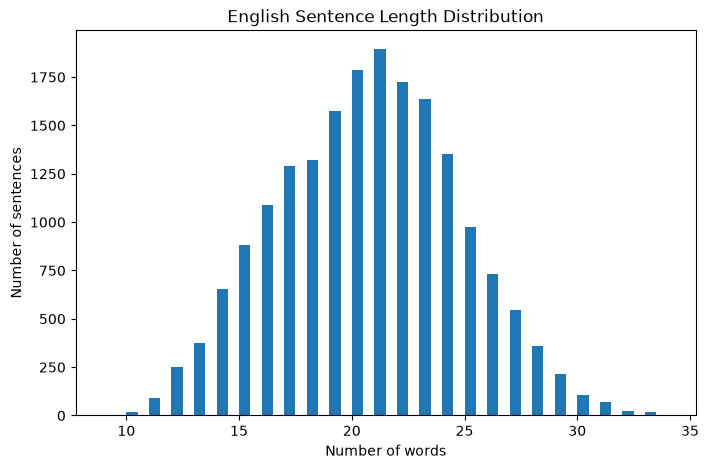

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    df["english_length"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("English Sentence Length Distribution")

plt.show()

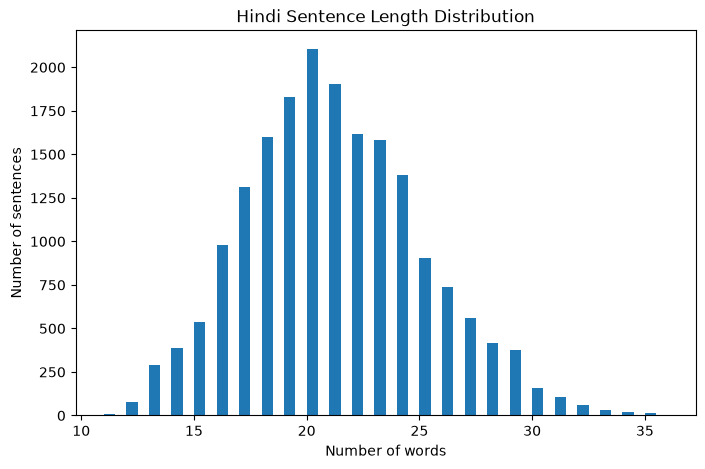

In [7]:
plt.figure(figsize=(8,5))
plt.hist(
    df["hindi_length"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("Hindi Sentence Length Distribution")

plt.show()

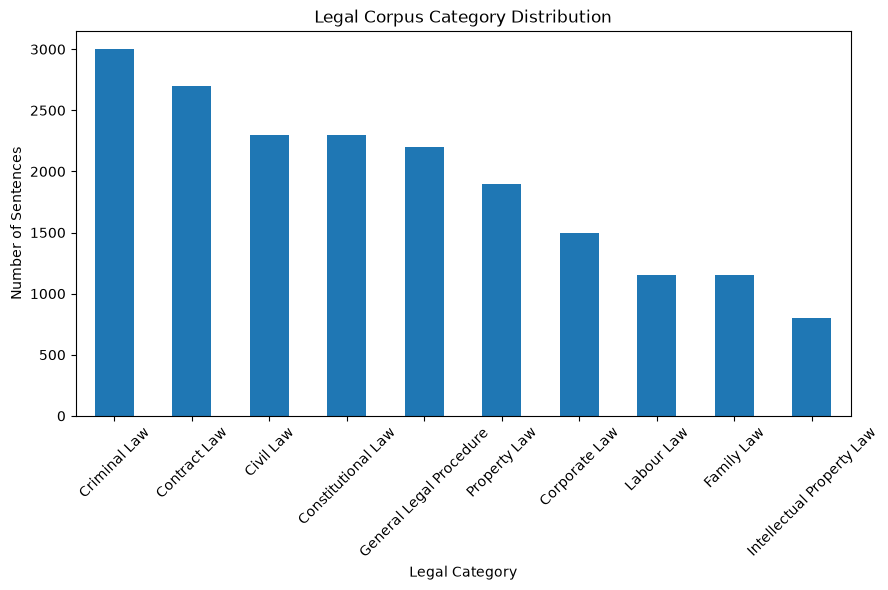

In [8]:
plt.figure(figsize=(10,5))

df["category"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Legal Category")
plt.ylabel("Number of Sentences")
plt.title("Legal Corpus Category Distribution")

plt.xticks(rotation=45)

plt.show()

# Text Preprocessing and Tokenization

In [9]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)#remove extra spaces
    text = text.strip()#remove trailing spaces
    return text

df["english"] = df["english"].apply(clean_text)
df["hindi"] = df["hindi"].apply(clean_text)

df.head()

,id,english,hindi,category,english_length,hindi_length
0,1,"Under the applicable statutory framework, the ...","प्रयोज्य सांविधिक ढांचे के अंतर्गत, ग्राहक क्ष...",Contract Law,15,17
1,2,"Subsequently, the vendor invoked the force maj...","तत्पश्चात, विक्रेता ने प्रतिफल के भुगतान के अन...",Contract Law,15,18
2,3,"At a subsequent stage of the proceedings, the ...","कार्यवाही के परवर्ती चरण में, पुलिस ने दोषी के...",Criminal Law,21,19
3,4,"As per settled legal principles, the co-owner ...","स्थापित विधिक सिद्धांतों के अनुसार, सह-स्वामी ...",Property Law,19,18
4,5,"In accordance with the prescribed procedure, t...","निर्धारित प्रक्रिया के अनुसार, दावेदार ने स्वत...",Civil Law,20,21


In [10]:
train_df,val_df = train_test_split(df,test_size=0.1,random_state=42)
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 17100
Validation samples: 1900


# SentencePiece Tokenization

In [11]:
create_tokenizer_corpus(
    train_df,
    "data/tokenizer/english_train.txt",
    "data/tokenizer/hindi_train.txt"
)

Tokenizer corpus created successfully.


In [12]:
train_tokenizer(
    input_file="data/tokenizer/english_train.txt",
    model_prefix="models/english_tokenizer",
    vocab_size=4000
)

print("English tokenizer created.")

English tokenizer created.


In [13]:
train_tokenizer(
    input_file="data/tokenizer/hindi_train.txt",
    model_prefix="models/hindi_tokenizer",
    vocab_size=3900
)

print("Hindi tokenizer created.")

Hindi tokenizer created.


# Creating PyTorch Dataset

In [14]:
english_sp, hindi_sp = load_tokenizers()

print("English Vocabulary:", english_sp.get_piece_size())
print("Hindi Vocabulary:", hindi_sp.get_piece_size())

English Vocabulary: 4000
Hindi Vocabulary: 3900


In [15]:
sample = train_df.iloc[0]

print("English:")
print(sample["english"])

print("\nTokens:")
print(english_sp.encode(sample["english"]))

print("\nHindi:")
print(sample["hindi"])

print("\nTokens:")
print(hindi_sp.encode(sample["hindi"]))

English:
The magistrate's court convicted the accused on the charge of criminal breach of trust and proceeded to hear arguments on sentencing.

Tokens:
[166, 643, 3989, 3956, 134, 410, 5, 463, 125, 5, 222, 15, 555, 335, 15, 1003, 101, 411, 32, 276, 409, 125, 412, 3968]

Hindi:
मजिस्ट्रेट न्यायालय ने अभियुक्त को आपराधिक न्यास भंग के आरोप में दोषसिद्ध किया और दंड पर तर्क सुनने हेतु आगे बढ़ा।

Tokens:
[584, 50, 23, 413, 39, 515, 937, 934, 5, 105, 27, 341, 58, 218, 348, 37, 272, 369, 85, 336, 368, 3866]


In [16]:
train_dataset = TranslationDataset(
    train_df,
    english_sp,
    hindi_sp
)

validation_dataset = TranslationDataset(
    val_df,
    english_sp,
    hindi_sp
)

train_dataset = torch.utils.data.Subset(
    train_dataset,
    range(5000)
)

print("Training Samples :", len(train_dataset))
print("Validation Samples:", len(validation_dataset))

Training Samples : 5000
Validation Samples: 1900


# Transformer Model Architecture

In [17]:
model = TransformerTranslator(
    src_vocab_size=english_sp.get_piece_size(),
    tgt_vocab_size=hindi_sp.get_piece_size(),
    d_model=256,
    nhead=8,
    num_layers=4
)

print(model)

TransformerTranslator(
  (src_embedding): Embedding(4000, 256)
  (tgt_embedding): Embedding(3900, 256)
  (position): PositionalEncoding()
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True

# Model Initialization and Training Setup

In [18]:
DEVICE = torch.device("cpu")

print("Using Device:", DEVICE)

model = TransformerTranslator(
    src_vocab_size=english_sp.get_piece_size(),
    tgt_vocab_size=hindi_sp.get_piece_size(),
    d_model=256,
    nhead=8,
    num_layers=4
)

model = model.to(DEVICE)

print("Model created successfully.")

Using Device: cpu
Model created successfully.


In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)
print("Training setup ready")

Training setup ready


In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False
)

# Training the Transformer Model

In [21]:
trained_model = train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    DEVICE,
    epochs=20
)

Epoch 1/20 Loss: 5.6094
Epoch 2/20 Loss: 3.0577
Epoch 3/20 Loss: 2.0881
Epoch 4/20 Loss: 1.5367
Epoch 5/20 Loss: 1.1733
Epoch 6/20 Loss: 0.9042
Epoch 7/20 Loss: 0.6959
Epoch 8/20 Loss: 0.5275
Epoch 9/20 Loss: 0.3972
Epoch 10/20 Loss: 0.3017
Epoch 11/20 Loss: 0.2318
Epoch 12/20 Loss: 0.1793
Epoch 13/20 Loss: 0.1417
Epoch 14/20 Loss: 0.1140
Epoch 15/20 Loss: 0.0914
Epoch 16/20 Loss: 0.0755
Epoch 17/20 Loss: 0.0628
Epoch 18/20 Loss: 0.0541
Epoch 19/20 Loss: 0.0465
Epoch 20/20 Loss: 0.0411


In [22]:
save_model(
    model,
    "models/legal_transformer.pt"
)
print("Model saved")

Model saved


# Inference Pipeline

In [23]:
model.eval()

print("Model ready for inference")

Model ready for inference


In [29]:
model, english_sp, hindi_sp = load_translation_model()

test_sentence = (
    "The Supreme Court granted bail to the accused person."
)

translation = translate(
    test_sentence,
    model,
    english_sp,
    hindi_sp
)

print("English:")
print(test_sentence)

print("\nHindi:")
print(translation)

English:
The Supreme Court granted bail to the accused person.

Hindi:
जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं विनिमय बोर्ड जीवन एवं
